In [1]:
import os
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Get the current root
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir_root = tf.keras.utils.get_file('flower_photos', origin=dataset_url, untar=True)

# 2. THE ULTIMATE PATH FIX:
# We are going into the sub-folder discovered by your last run
data_dir = os.path.join(data_dir_root, 'flower_photos')

# 3. VERIFICATION (Check this output carefully!)
if os.path.exists(data_dir):
    subdirs = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    print("Categories found in folder:", subdirs)
else:
    # If the above fails, use the parent directory
    data_dir = data_dir_root
    subdirs = [f for f in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, f))]
    print("Categories found in root:", subdirs)

# 4. Generators
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='training'
)
val_gen = datagen.flow_from_directory(
    data_dir, target_size=(224, 224), batch_size=32,
    class_mode='categorical', subset='validation', shuffle=False
)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
Categories found in folder: ['tulips', 'dandelion', 'daisy', 'sunflowers', 'roses']
Found 2939 images belonging to 5 classes.
Found 731 images belonging to 5 classes.


In [2]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Load ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

# Custom Head
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)

# PHASE 1: Train Head Only
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Starting Phase 1...")
history_p1 = model.fit(train_gen, validation_data=val_gen, epochs=3)

# PHASE 2: Fine-Tuning
base_model.trainable = True
for layer in base_model.layers[:-10]: # Freeze all but last 10
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
print("Starting Phase 2...")
history_p2 = model.fit(train_gen, validation_data=val_gen, epochs=3)

model.save("best_model.keras")

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Starting Phase 1...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 244ms/step - accuracy: 0.2422 - loss: 1.6973 - val_accuracy: 0.3639 - val_loss: 1.5087
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 116ms/step - accuracy: 0.3243 - loss: 1.5246 - val_accuracy: 0.3680 - val_loss: 1.5016
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.3403 - loss: 1.5125 - val_accuracy: 0.3748 - val_loss: 1.4738
Starting Phase 2...
Epoch 1/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 37s 249ms/step - accuracy: 0.2729 - loss: 1.8219 - val_accuracy: 0.3393 - val_loss: 1.5037
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.4042 - loss: 1.4425 - val_accuracy: 0.3365 - val_loss: 1.4897
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.4472 - loss: 1.3617 - val_accuracy: 0.3926 - val_loss: 1.4426


In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(train_gen.num_classes, activation='softmax')
])

baseline.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
print("Training Baseline...")
history_baseline = baseline.fit(train_gen, validation_data=val_gen, epochs=3)

Training Baseline...
Epoch 1/3


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


92/92 ━━━━━━━━━━━━━━━━━━━━ 15s 129ms/step - accuracy: 0.2790 - loss: 10.4250 - val_accuracy: 0.3352 - val_loss: 1.3751
Epoch 2/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.3889 - loss: 1.2988 - val_accuracy: 0.3721 - val_loss: 1.3344
Epoch 3/3
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step - accuracy: 0.4542 - loss: 1.1401 - val_accuracy: 0.3680 - val_loss: 1.3653


In [4]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
import tensorflow as tf

# Load Pre-trained ResNet50
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# --- PHASE 1: Feature Extraction ---
base_model.trainable = False  # Freeze the base

x = GlobalAveragePooling2D()(base_model.output)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
predictions = Dense(train_gen.num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting Phase 1: Training the Head...")
history_p1 = model.fit(train_gen, validation_data=val_gen, epochs=5)

# --- PHASE 2: Fine-Tuning ---
base_model.trainable = True # Unfreeze the base

# Re-freeze all layers except the last 10 to protect early features
for layer in base_model.layers[:-10]:
    layer.trainable = False

# Re-compile with VERY low learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              loss='categorical_crossentropy', metrics=['accuracy'])

print("Starting Phase 2: Fine-Tuning top layers...")
history_p2 = model.fit(train_gen, validation_data=val_gen, epochs=5)

model.save("best_model.keras")

Starting Phase 1: Training the Head...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 31s 227ms/step - accuracy: 0.2541 - loss: 1.7901 - val_accuracy: 0.3639 - val_loss: 1.5032
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - accuracy: 0.3215 - loss: 1.5316 - val_accuracy: 0.3721 - val_loss: 1.4863
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 21s 113ms/step - accuracy: 0.3670 - loss: 1.5043 - val_accuracy: 0.3461 - val_loss: 1.4866
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.3640 - loss: 1.4926 - val_accuracy: 0.3830 - val_loss: 1.4542
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.3578 - loss: 1.4855 - val_accuracy: 0.3570 - val_loss: 1.4661
Starting Phase 2: Fine-Tuning top layers...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 35s 243ms/step - accuracy: 0.3262 - loss: 1.8041 - val_accuracy: 0.3338 - val_loss: 1.5076
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.4219 - loss: 1.3974 - val_accuracy: 0.3365 - val_loss: 1.4992
Epoch 3/5
92/92 ━━━━━

In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

baseline_model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(train_gen.num_classes, activation='softmax')
])

baseline_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("Training Baseline Model for Comparison...")
history_baseline = baseline_model.fit(train_gen, validation_data=val_gen, epochs=5)

Training Baseline Model for Comparison...
Epoch 1/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 17s 142ms/step - accuracy: 0.3569 - loss: 3.3476 - val_accuracy: 0.5609 - val_loss: 1.0758
Epoch 2/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 99ms/step - accuracy: 0.6418 - loss: 0.9345 - val_accuracy: 0.5773 - val_loss: 1.1445
Epoch 3/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 94ms/step - accuracy: 0.8260 - loss: 0.5395 - val_accuracy: 0.6005 - val_loss: 1.2034
Epoch 4/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step - accuracy: 0.9419 - loss: 0.2031 - val_accuracy: 0.5937 - val_loss: 1.4944
Epoch 5/5
92/92 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - accuracy: 0.9803 - loss: 0.0849 - val_accuracy: 0.5691 - val_loss: 1.8921


23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 272ms/step
Classification Report:
              precision    recall  f1-score   support

       daisy       0.57      0.52      0.55       126
   dandelion       0.48      0.85      0.61       179
       roses       0.38      0.02      0.04       128
  sunflowers       0.40      0.48      0.44       139
      tulips       0.55      0.43      0.48       159

    accuracy                           0.49       731
   macro avg       0.48      0.46      0.42       731
weighted avg       0.48      0.49      0.44       731



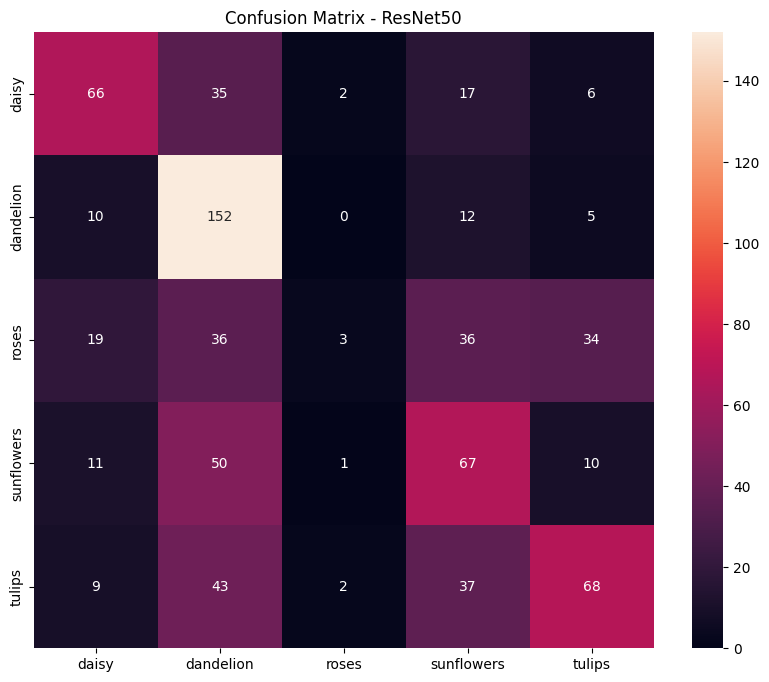

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_185']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


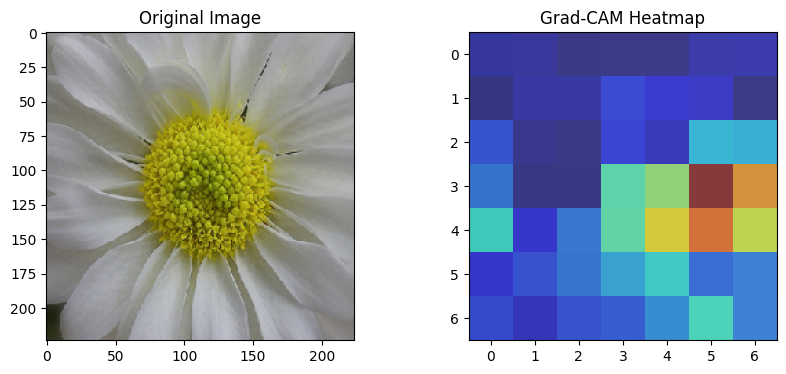

In [6]:
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Classification Metrics
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)

print('Classification Report:')
print(classification_report(val_gen.classes, y_pred, target_names=list(train_gen.class_indices.keys())))

# 2. Confusion Matrix
cm = confusion_matrix(val_gen.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
plt.title('Confusion Matrix - ResNet50')
plt.show()

# 3. Grad-CAM Function
def get_gradcam_heatmap(img_array, model, last_conv_layer_name):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        class_channel = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(class_channel, last_conv_layer_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = last_conv_layer_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Visualize Grad-CAM
img, label = next(val_gen)
heatmap = get_gradcam_heatmap(img[0:1], model, 'conv5_block3_out')

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Original Image")
plt.subplot(1,2,2)
plt.imshow(img[0])
plt.imshow(heatmap, alpha=0.6, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.show()

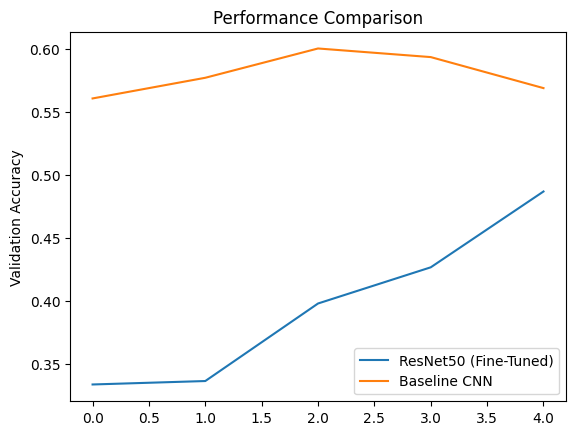

In [7]:
plt.plot(history_p2.history['val_accuracy'], label='ResNet50 (Fine-Tuned)')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline CNN')
plt.title('Performance Comparison')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.show()

23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step


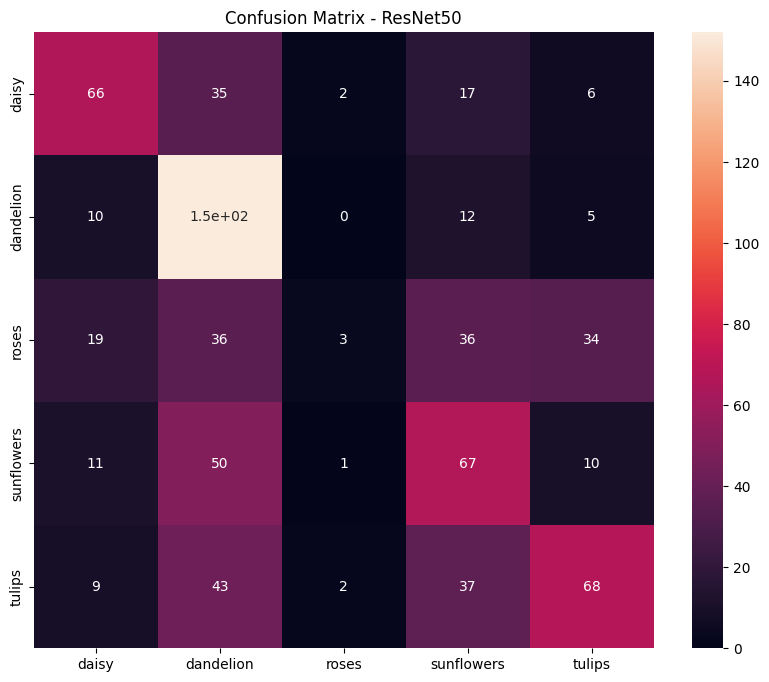

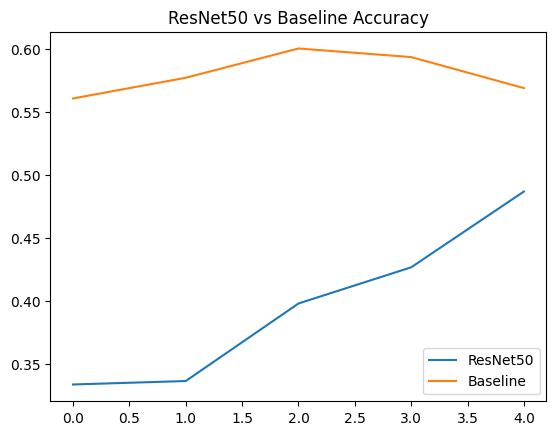

In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
# Predictions
Y_pred = model.predict(val_gen)
y_pred = np.argmax(Y_pred, axis=1)

# Confusion Matrix
cm = confusion_matrix(val_gen.classes, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, xticklabels=val_gen.class_indices.keys(), yticklabels=val_gen.class_indices.keys())
plt.title('Confusion Matrix - ResNet50')
plt.show()

# Accuracy Comparison Plot
plt.plot(history_p2.history['val_accuracy'], label='ResNet50')
plt.plot(history_baseline.history['val_accuracy'], label='Baseline')
plt.title('ResNet50 vs Baseline Accuracy')
plt.legend()
plt.show()

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['keras_tensor_185']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


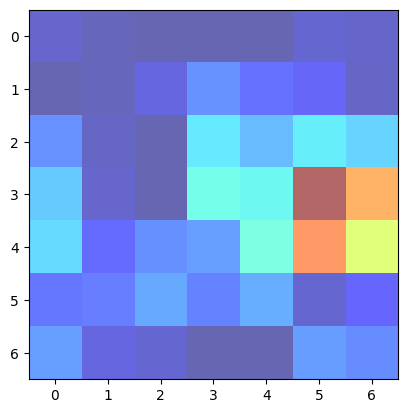

In [9]:
def get_gradcam(img_array, model, last_conv_layer_name):
    grad_model = Model([model.inputs], [model.get_layer(last_conv_layer_name).output, model.output])
    with tf.GradientTape() as tape:
        last_conv_output, preds = grad_model(img_array)
        class_channel = preds[:, np.argmax(preds[0])]

    grads = tape.gradient(class_channel, last_conv_output)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = last_conv_output[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# Show Grad-CAM for one image
img, label = next(val_gen)
heatmap = get_gradcam(img[0:1], model, 'conv5_block3_out')
plt.imshow(img[0])
plt.imshow(heatmap, alpha=0.6, cmap='jet') # Overlay heatmap
plt.show()